# AlphaFold pLDDT at exon-exon junctions

Does local model confidence (pLDDT) relate to where introns interrupt the
protein? Using `fastCDS` we know, for every protein, exactly which residue
each exon-exon junction falls on. We line those junctions up against the
per-residue pLDDT of the **whole human canonical proteome** from the AlphaFold
Database and ask whether confidence changes near a junction.

Pipeline (each heavy step is cache-aware):

1. Map every canonical ENSP → UniProt accession (Ensembl BioMart r115).
2. Fetch per-residue pLDDT for each canonical protein from AlphaFold DB (v6).
3. Recover exon-exon junction residue positions with `fastCDS`.
4. Average pLDDT as a function of residue distance to the nearest junction.

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Every figure saved as PNG also gets a vector PDF (same bbox/dimensions) under
# tutorial/reproduce_paper/figures_pdf/ (right next to these notebooks), so the
# paper figures are available as scalable PDFs without changing any plotting code.
from pathlib import Path as _Path
import os as _os
FIGDIR = (_Path.home() / "Desktop" / "fastCDS" / "tutorial"
          / "reproduce_paper" / "figures_pdf")
FIGDIR.mkdir(parents=True, exist_ok=True)
if not getattr(mpl.figure.Figure.savefig, "_writes_pdf", False):  # guard: don't double-wrap
    _orig_savefig = mpl.figure.Figure.savefig
    def _savefig_both(self, fname, *a, **k):
        _orig_savefig(self, fname, *a, **k)
        s = str(fname)
        if s.lower().endswith(".png"):
            kk = dict(k); kk.pop("dpi", None)              # vector PDF: drop raster dpi
            _orig_savefig(self, str(FIGDIR / (_os.path.splitext(_os.path.basename(s))[0] + ".pdf")), *a, **kk)
    _savefig_both._writes_pdf = True
    mpl.figure.Figure.savefig = _savefig_both

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'fastCDS':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, json, pickle, time, urllib.parse, urllib.request, urllib.error, subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

DATA = Path.home() / "Desktop" / "protein2genomic_data"
IDX  = DATA / "human_v115.idx"
MAP  = DATA / "ensp_uniprot_v115.tsv"
PKL  = DATA / "af_plddt.pkl"
WIN, JUNC, CORE_LO, CORE_HI = 30, 1, 6, 15
print("data dir:", DATA)

data dir: /home/goguxor/Desktop/protein2genomic_data


## 1. ENSP → UniProt (BioMart r115)

One canonical protein per gene, with its Swiss-Prot accession — that is the
sequence AlphaFold models.

In [2]:
def pull_ensp_uniprot(out):
    host = "https://www.ensembl.org/biomart/martservice"
    chroms = [str(i) for i in range(1, 23)] + ["X", "Y"]
    def xml(c):
        return ('<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query>'
            '<Query virtualSchemaName="default" formatter="TSV" header="0" '
            'uniqueRows="1" count="" datasetConfigVersion="0.6">'
            '<Dataset name="hsapiens_gene_ensembl" interface="default">'
            f'<Filter name="chromosome_name" value="{c}"/>'
            '<Attribute name="ensembl_peptide_id"/>'
            '<Attribute name="uniprotswissprot"/>'
            '<Attribute name="transcript_is_canonical"/></Dataset></Query>')
    rows = {}
    for c in chroms:
        url = host + "?" + urllib.parse.urlencode({"query": xml(c)})
        with urllib.request.urlopen(url, timeout=180) as r:
            for ln in r.read().decode().splitlines():
                f = ln.split("\t")
                if len(f) < 2 or not f[0] or not f[1]:
                    continue
                rows[f[0]] = (f[1], len(f) > 2 and f[2] == "1")
    with open(out, "w") as fh:
        fh.write("protein_id\tuniprot\tis_canonical\n")
        for e, (u, c) in rows.items():
            fh.write(f"{e}\t{u}\t{int(c)}\n")
    return len(rows)

if not MAP.exists():
    pull_ensp_uniprot(MAP)
m = pd.read_csv(MAP, sep="\t")
canon = m[(m.is_canonical == 1) & m.uniprot.notna()].drop_duplicates("protein_id")
print(f"{len(canon):,} canonical proteins with a UniProt accession")

18,806 canonical proteins with a UniProt accession


## 2. Per-residue pLDDT from AlphaFold DB (v6)

One small JSON per protein (`AF-<acc>-F1-confidence_v6.json`) holds the
per-residue pLDDT. Fetched in parallel; ~1 % of proteins have no AF model.
Cached to `af_plddt.pkl`.

In [3]:
URL = "https://alphafold.ebi.ac.uk/files/AF-{}-F1-confidence_v6.json"
def fetch(ensp, up):
    for _ in range(3):
        try:
            with urllib.request.urlopen(URL.format(up), timeout=30) as r:
                return ensp, up, np.asarray(json.loads(r.read())["confidenceScore"],
                                            dtype=np.float32)
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return ensp, up, None
            time.sleep(2)
        except Exception:
            time.sleep(2)
    return ensp, up, None

if PKL.exists():
    af = pickle.load(open(PKL, "rb"))
    print(f"(cached) {len(af):,} proteins with pLDDT")
else:
    af = {}
    with ThreadPoolExecutor(max_workers=16) as ex:
        futs = [ex.submit(fetch, r.protein_id, r.uniprot)
                for r in canon.itertuples(index=False)]
        for i, f in enumerate(as_completed(futs)):
            e, u, pl = f.result()
            if pl is not None:
                af[e] = {"uniprot": u, "plddt": pl}
            if (i + 1) % 2000 == 0:
                print(f"  {i+1}/{len(futs)}")
    pickle.dump(af, open(PKL, "wb"))
    print(f"{len(af):,} proteins with pLDDT")

(cached) 18,484 proteins with pLDDT


## 3. Exon-exon junction residue positions

Map each protein over its full length; the cumulative CDS-exon nucleotide
lengths give the residue at every internal junction. We keep proteins whose
Ensembl length matches the AlphaFold sequence length (so residue indices line
up).

In [4]:
bedp = DATA / "af_proteins.bed"
with open(bedp, "w") as fh:
    for ensp, rec in af.items():
        fh.write(f"{ensp}\t1\t{len(rec['plddt'])}\tFULL_{ensp}\n")

import fastCDS as fc
if not IDX.exists():                          # build the shared r115 index if absent
    import gzip, shutil, urllib.request
    gtf = DATA / "Homo_sapiens.GRCh38.115.gtf"
    if not gtf.exists():
        gz = DATA / "Homo_sapiens.GRCh38.115.gtf.gz"
        if not gz.exists():
            urllib.request.urlretrieve("https://ftp.ensembl.org/pub/release-115/"
                "gtf/homo_sapiens/Homo_sapiens.GRCh38.115.gtf.gz", gz)
        with gzip.open(gz, "rb") as fi, open(gtf, "wb") as fo:
            shutil.copyfileobj(fi, fo)
    fc.build_index(str(gtf), out=str(IDX))

outdir = DATA / "af_struct"
if not (outdir / "domain_cds_segments.tsv").exists():
    fc.Mapper(index=str(IDX), threads=os.cpu_count() or 1).map_batch(
        pd.read_csv(bedp, sep="\t", header=None,
                    names=["protein_id", "aa_start", "aa_end", "domain_id"]),
        output="coding", keep_outputs=str(outdir))

seg = pd.read_csv(outdir / "domain_cds_segments.tsv", sep="\t", low_memory=False)
seg["cds_k"] = seg["feature_id"].str.extract(r"CDS_(\d+)").astype("Int64")
exlen = (seg[seg.cds_k.notna()].groupby(["input_id", "cds_k"])["feature_length_nt"]
            .sum().reset_index())
print(f"structure for {exlen.input_id.nunique():,} proteins")

structure for 18,484 proteins


## 4. Per-residue pLDDT vs distance to the nearest junction

An **exon-exon junction** is the coordinate where one exon ends and the next
begins — the exon/intron boundary (splice site). We keep only residues in
**internal CDS exons** (dropping the amino acids that fall in the first and last
exon, which border the CDS ends rather than a junction on one side). For each
such residue we take the middle nt of its codon and its two flanking junctions
and record the **nt distance to the nearest one**, then **truncate at 90 nt** to
focus on the splice-site neighbourhood (a residue right at a boundary = 0).

In [5]:
plddt_all, nt_all = [], []
n_used = n_mm = 0
for ensp, grp in exlen.groupby("input_id"):
    rec = af.get(ensp.replace("FULL_", ""))
    if rec is None:
        continue
    pl = rec["plddt"]; L = len(pl)
    nt = grp.sort_values("cds_k")["feature_length_nt"].to_numpy()
    n = len(nt)
    if abs(int(nt.sum()//3) - L) > 1 or n < 3:        # need >=3 exons for an internal one
        n_mm += 1; continue
    cum = np.cumsum(nt)                                # 1-based nt at each exon's 3' end
    res_m = np.arange(L) * 3 + 2                       # middle nt of each codon (1-based)
    k = np.clip(np.searchsorted(cum, res_m, side="left"), 0, n - 1)   # exon index per residue
    internal = (k >= 1) & (k <= n - 2)                # drop first (0) and last (n-1) exon
    if not internal.any():
        continue
    ki = k[internal]; rm = res_m[internal]
    up, down = cum[ki - 1], cum[ki]
    nearest = np.minimum(rm - up, down - rm).astype(float)        # nt to nearest boundary, >=0
    plddt_all.append(pl[:L][internal]); nt_all.append(nearest)
    n_used += 1

plddt = np.concatenate(plddt_all).astype(float)
ntd   = np.concatenate(nt_all).astype(float)
WIN_NT = 90
keep = ntd <= WIN_NT                                  # truncate at 90 nt
plddt_w, dist_w = plddt[keep], ntd[keep]
print(f"{n_used:,} multi-exon proteins, {len(plddt):,} internal-exon residues "
      f"(dropped {n_mm:,} length-mismatch / <3-exon)")
print(f"within {WIN_NT} nt of a junction: {len(dist_w):,} residues ({100*keep.mean():.1f}%)")

14,258 multi-exon proteins, 6,005,914 internal-exon residues (dropped 4,226 length-mismatch / <3-exon)
within 90 nt of a junction: 5,134,323 residues (85.5%)


## 5. Figure — distance vs pLDDT, one panel per AlphaFold confidence range

Four panels, **one per AlphaFold pLDDT confidence range** (very low < 50, low
50-70, confident 70-90, very high > 90), built from internal-exon residues within
90 nt of a junction. All panels **share the Y axis** (nt distance to the nearest
exon-exon junction, truncated at 90) and each panel's **X axis spans its own pLDDT
range**, showing its **own 2D density KDE** (sequential palette, darker = denser,
normalised within the panel so even the sparse low-confidence ranges show
structure). The confidence colour key is the **categorical bar along the
bottom**.

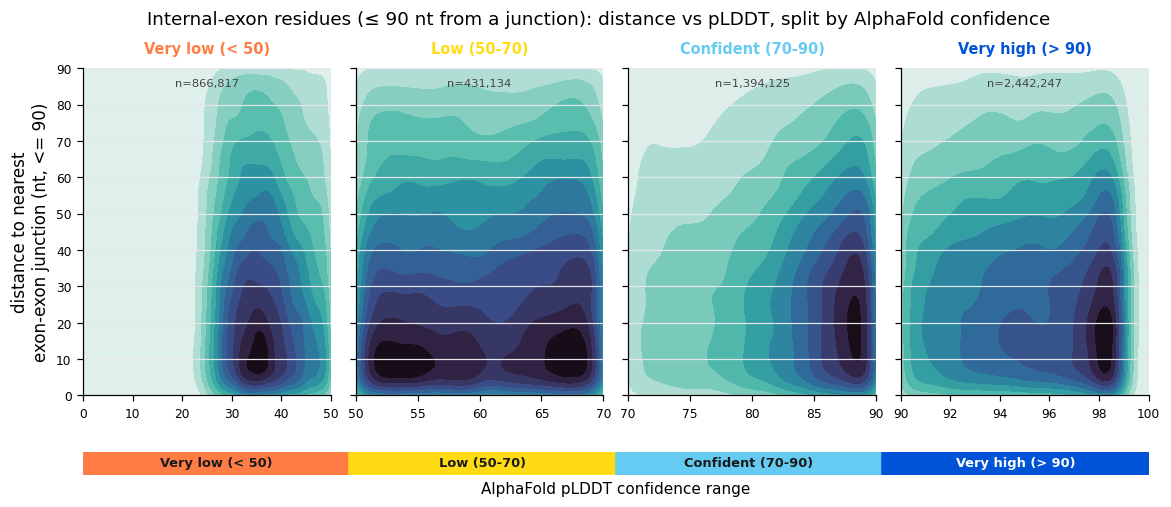

In [6]:
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

# nice sequential palette (mako-like): light = sparse -> dark = dense
mako = LinearSegmentedColormap.from_list("mako_like", [
    "#f4f6f5", "#a8dbcf", "#5bbfae", "#2c9aa0", "#2e6f9e",
    "#3a4b86", "#35264c", "#0b0405"])
# AlphaFold DB confidence ranges (lo, hi, colour, label)
BANDS = [(0, 50, "#FF7D45", "Very low (< 50)"), (50, 70, "#FFDB13", "Low (50-70)"),
         (70, 90, "#65CBF3", "Confident (70-90)"), (90, 100, "#0053D6", "Very high (> 90)")]
rng = np.random.default_rng(0)

fig = plt.figure(figsize=(12.5, 4.8))
gs = fig.add_gridspec(2, 4, height_ratios=[14, 1], hspace=0.32, wspace=0.10)
ax0 = fig.add_subplot(gs[0, 0])
panels = [ax0] + [fig.add_subplot(gs[0, i], sharey=ax0) for i in range(1, 4)]
for ax, (lo, hi, col, lab) in zip(panels, BANDS):
    sel = (plddt_w >= lo) & (plddt_w < (hi + 0.01 if hi == 100 else hi))
    px, py = plddt_w[sel], dist_w[sel]
    s = rng.choice(len(px), min(40000, len(px)), replace=False)   # own KDE per panel
    kde = gaussian_kde(np.vstack([px[s], py[s]]))
    gx, gy = np.mgrid[lo:hi:120j, 0:WIN_NT:170j]
    zz = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contourf(gx, gy, zz, levels=12, cmap=mako)
    ax.set_xlim(lo, hi); ax.set_ylim(0, WIN_NT)
    ax.set_title(lab, color=col, fontsize=9.5, fontweight="bold"); ax.tick_params(labelsize=8)
    ax.text(0.5, 0.97, f"n={int(sel.sum()):,}", transform=ax.transAxes, ha="center",
            va="top", fontsize=7.5, color="#444")
panels[0].set_ylabel("distance to nearest\nexon-exon junction (nt, <= 90)")
for ax in panels[1:]:
    ax.tick_params(labelleft=False)
barax = fig.add_subplot(gs[1, :])
for i, (lo, hi, col, lab) in enumerate(BANDS):
    barax.axvspan(i, i + 1, color=col)
    barax.text(i + 0.5, 0.5, lab, ha="center", va="center", fontsize=8.5,
               fontweight="bold", color="white" if col == "#0053D6" else "#1a1a1a")
barax.set_xlim(0, 4); barax.set_ylim(0, 1); barax.set_xticks([]); barax.set_yticks([])
for sp in barax.spines.values():
    sp.set_visible(False)
barax.set_xlabel("AlphaFold pLDDT confidence range", fontsize=10)
fig.suptitle("Internal-exon residues (≤ 90 nt from a junction): distance vs pLDDT, "
             "split by AlphaFold confidence", fontsize=12, y=0.99)
display(fig)
fig.savefig(DATA / "fig_analysis4_plddt.png", bbox_inches="tight")